## Import Libraries and Packages

In [121]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

mne.set_log_level("WARNING")

## Load Dataset and All Subjects

In [122]:
# load all data file paths into eeg_files
data_path = Path("ds004504-download")
eeg_files = sorted(list(data_path.glob("sub-*/eeg/*.set")))

In [123]:
# display total num of subjects
print("Number of Subjects:", len(eeg_files))

Number of Subjects: 88


# Exploratory Data Analysis (With One Subject)

In [124]:
# first understand + explore data with 1 subject
file = eeg_files[0]
raw = mne.io.read_raw_eeglab(file, preload=True)

In [125]:
# print stats like # of channels, sampling rate, duration
print("Number of Channels:", len(raw.ch_names))
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info["sfreq"])
print("Recording duration (sec):", raw.times[-1])

Number of Channels: 19
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Sampling rate: 500.0
Recording duration (sec): 599.798


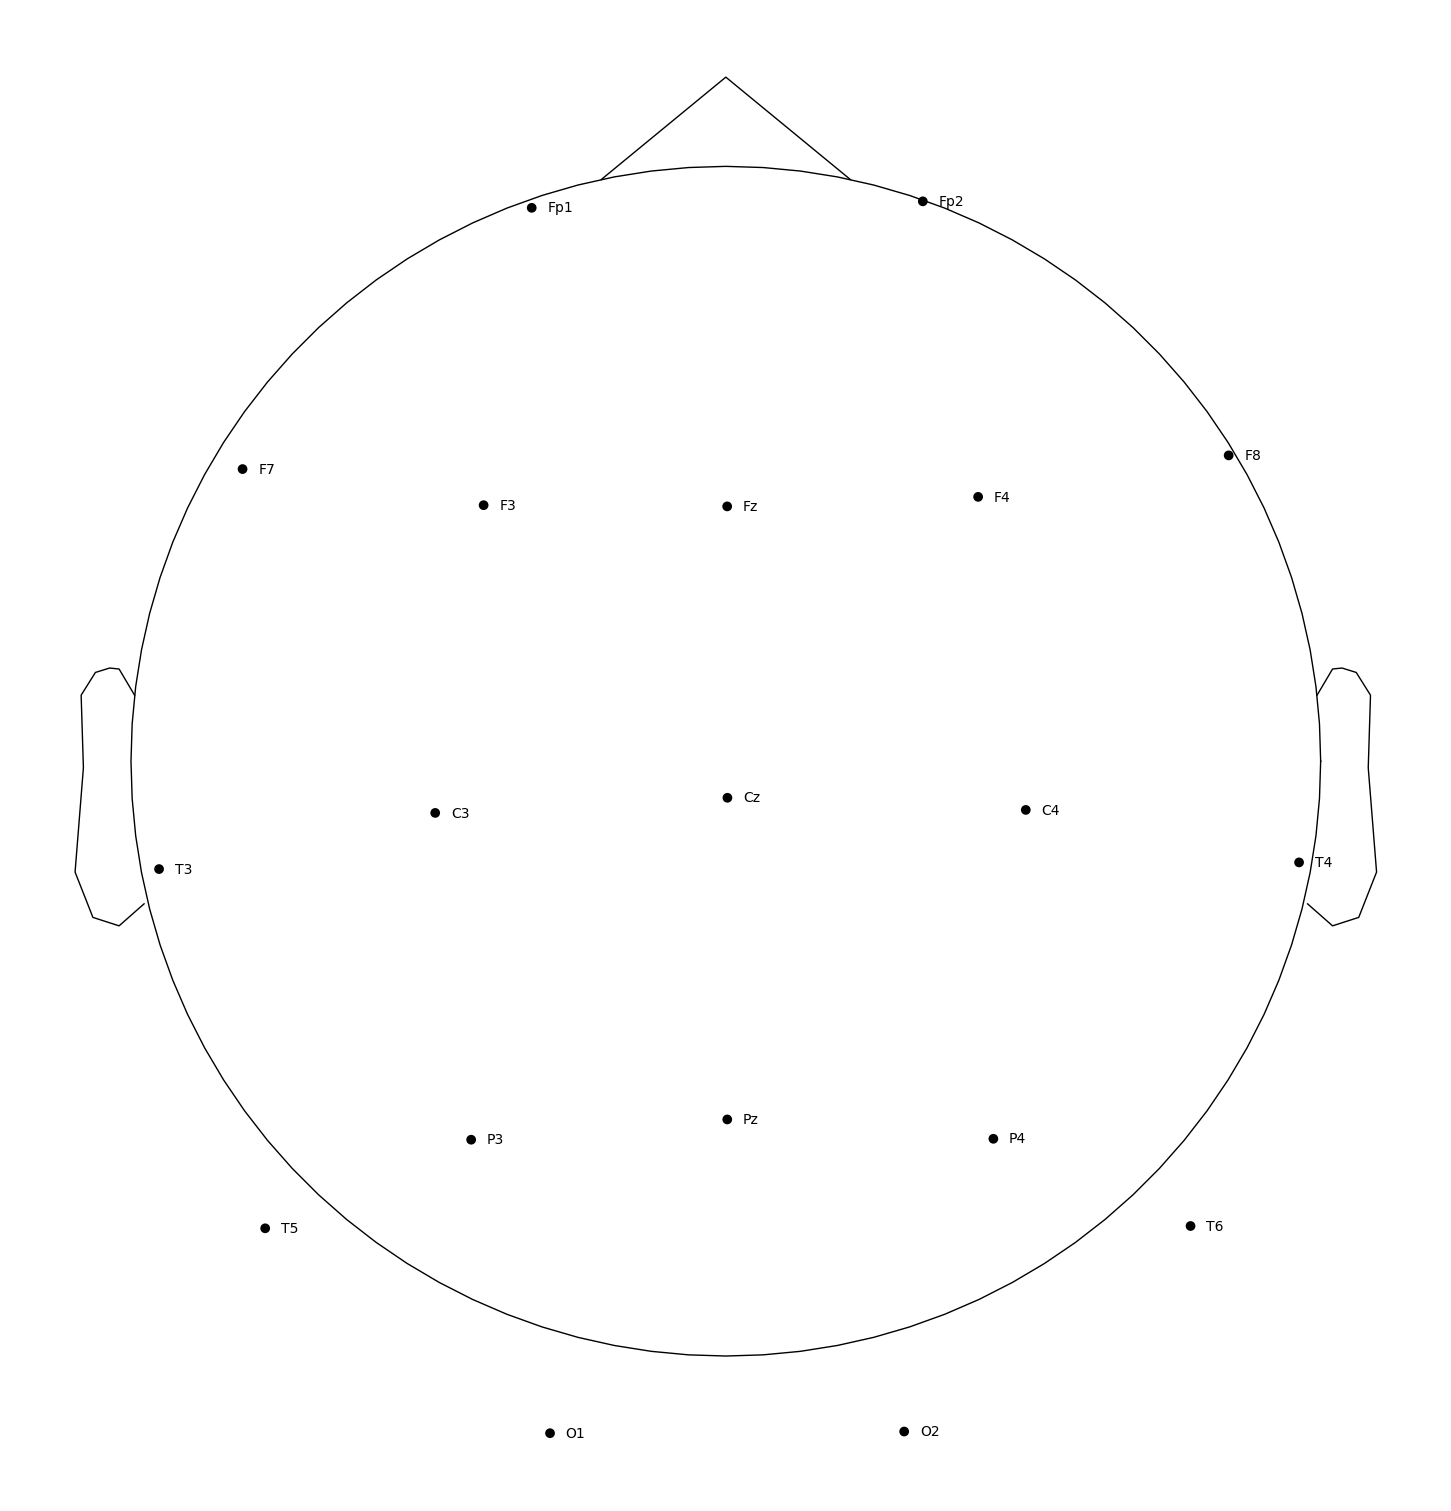

In [126]:
# visualize scalp electrode positions
raw.plot_sensors(show_names=True);

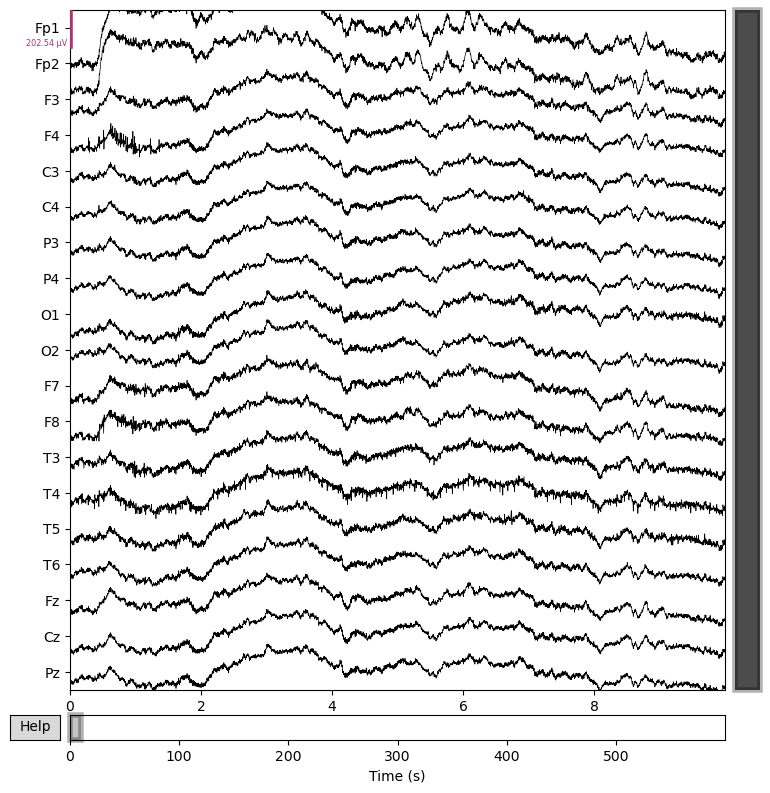

In [127]:
# visualize raw signal for one subject, first 10 seconds
raw.plot(duration=10, n_channels=len(raw.ch_names), scalings="auto");

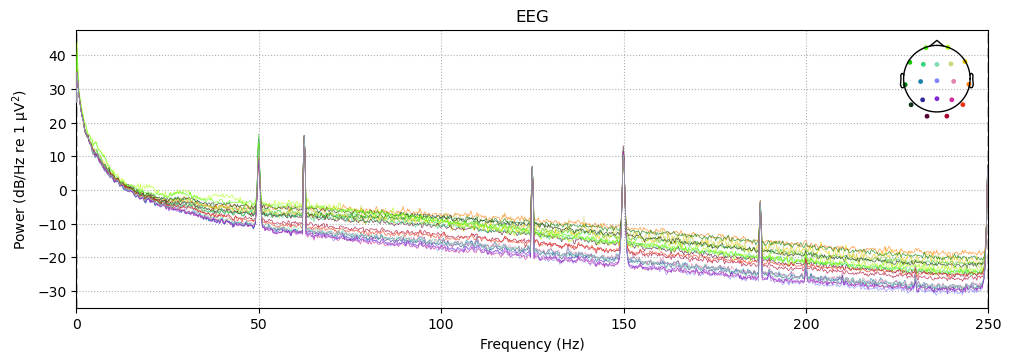

In [128]:
# look at power spectrum
raw.compute_psd().plot();

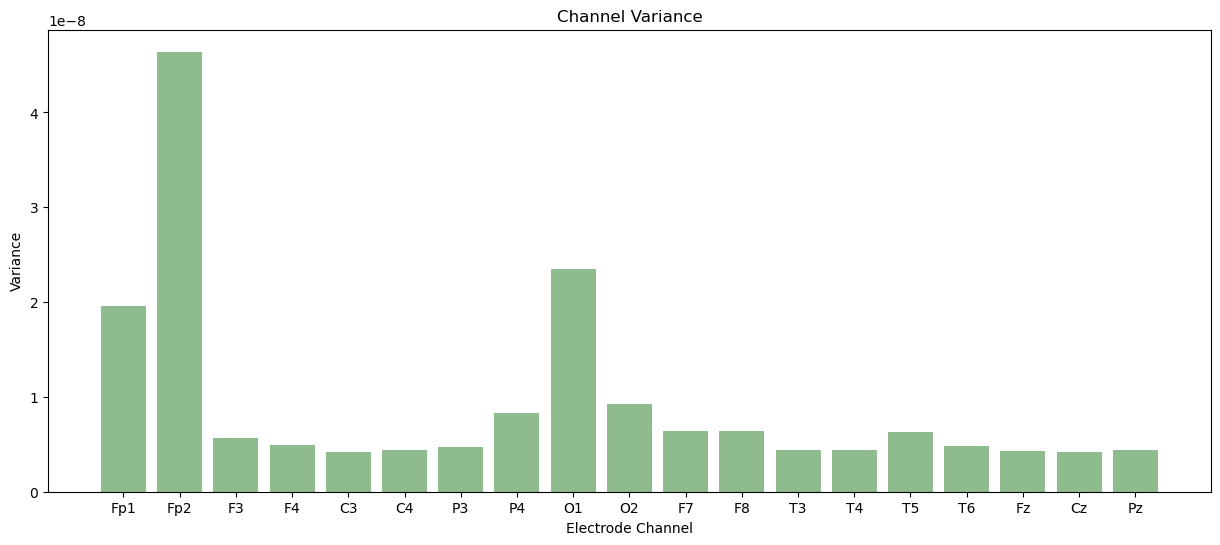

In [129]:
# look at noisiness of electrodes
data = raw.get_data()

variance = np.var(data, axis=1)

plt.figure(figsize=(15, 6))
plt.bar(raw.ch_names, variance, color="darkseagreen")
plt.title("Channel Variance")
plt.xlabel("Electrode Channel")
plt.ylabel("Variance");

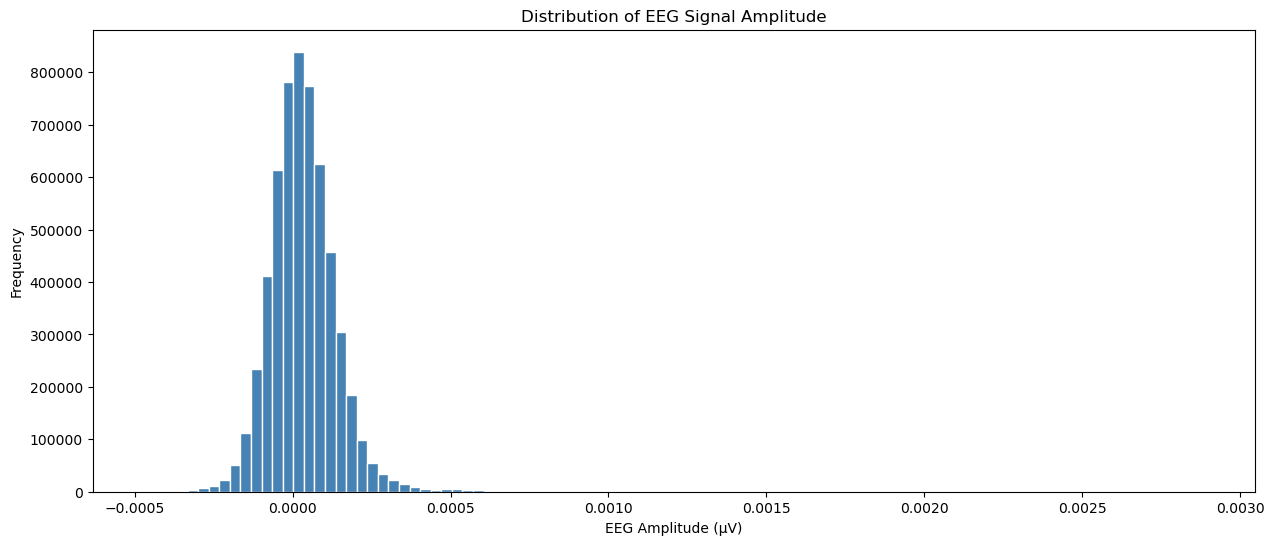

In [141]:
flattened = data.flatten()
plt.figure(figsize=(15, 6))
plt.hist(flattened, bins=100, edgecolor="white", color="steelblue")
plt.title("Distribution of EEG Signal Amplitude")
plt.xlabel("EEG Amplitude (µV)")
plt.ylabel("Frequency");

In [142]:
# some stats across subjects
durations = []
channels = []
sfreqs = []

for file in eeg_files:
    raw = mne.io.read_raw_eeglab(file, preload=False)
    durations.append(raw.times[-1])
    channels.append(len(raw.ch_names))
    sfreqs.append(raw.info["sfreq"])
print("Average duration:", np.mean(durations), "seconds")
print("Channels:", np.unique(channels)[0])
print("Sampling rate:", np.unique(sfreqs)[0], "Hz")

Average duration: 802.1605 seconds
Channels: 19
Sampling rate: 500.0 Hz
